In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Coupling and Delays

A whole-brain model is more than a collection of independent regions — it is a
*network*. This page explains the three ingredients that wire regions together:
the **structural connectivity** (who connects to whom), the **conduction delays**
(how long a signal takes to travel), and the **coupling function** (how a
neighbour's activity enters a region's dynamics). It covers the maths and the
intuition; the hands-on recipe is {doc}`/howto/custom_coupling`, and the API is
``brainmass.Network`` and the ``*Coupling`` classes.

## Structural connectivity (SC)

The wiring diagram of a brain network is a **structural connectivity matrix**
$W \in \mathbb{R}^{N \times N}$ for $N$ regions. Each entry $W_{ij}$ is the strength
of the anatomical connection from region $j$ to region $i$, typically estimated
from diffusion-MRI **tractography** (streamline counts between parcels) or taken
from a tract-tracing atlas.

Conventions that matter in practice:

- **No self-connections.** The diagonal $W_{ii}$ is usually zeroed — a region's
  recurrent dynamics live *inside* its own neural mass model, not in the SC.
  ``brainmass.Network`` zeroes the diagonal for you (unless you opt in with
  ``self_connection=True``).
- **Weights are non-negative** and often normalised (e.g. to $[0,1]$, or row-/
  Laplacian-normalised). A global scalar $k$ (TVB calls it $G$; ``brainmass`` keeps
  the convention $G \equiv k$) sets the overall coupling strength on top of $W$.
- **Symmetry** is common for diffusion-MRI SC (tractography is undirected) but not
  required; directed connectomes are supported.

The bundled ``datasets.load_dataset('example_connectome')`` provides a small
symmetric $8 \times 8$ $W$ (plus a distance matrix) to experiment with.

## Conduction delays

Axons conduct at a finite speed, so a signal leaving region $j$ arrives at region
$i$ only after a **conduction delay**

$$
\tau_{ij} \;=\; \frac{d_{ij}}{v},
$$

where $d_{ij}$ is the fibre length between the regions (a **distance matrix**,
often in mm) and $v$ is the conduction speed (mm/ms, typically a few m/s for
myelinated white-matter tracts). Delays are essential: they are what let a network
of identical oscillators produce travelling waves, metastable switching, and
realistic resting-state dynamics rather than collapsing to global synchrony.

With delays, the coupling that region $i$ feels at time $t$ reads the *past* state
of its sources:

$$
\text{input}_i(t) \;\propto\; \sum_j W_{ij}\, x_j\!\left(t - \tau_{ij}\right).
$$

Numerically this needs a **delay buffer** — a ring buffer of recent history sized
from $\max_{ij}\tau_{ij} / \Delta t$ steps. ``brainmass`` builds this for you when
you pass ``distance`` and ``speed`` to ``Network``; if either is omitted the
coupling is **instantaneous** (zero delays). Units are handled automatically: if
``distance`` carries length units and ``speed`` carries length/time units, the
delay is unit-correct; plain numbers are assumed to be milliseconds. The
self-delay (the diagonal of $\tau$) is always zeroed.

> One practical wrinkle: ``Network`` sizes its delay buffer from the global ``dt``
> at *construction* time, so set ``brainstate.environ.set(dt=…)`` before building a
> delay-coupled network. The ``Simulator`` then drives it with that same ``dt``.

## How activity enters a region: three coupling functions

Given the (possibly delayed) source activity and the SC, a **coupling function**
turns them into the current that drives each region. ``brainmass`` provides three
families. The choice is a modelling decision with real dynamical consequences.

### Diffusive coupling

Diffusive coupling drives a region by the **difference** between its neighbours'
activity and its own:

$$
\text{current}_i \;=\; k \sum_j W_{ij}\,\bigl(x_j^{(\tau)} - y_i\bigr),
$$

where $x_j^{(\tau)}$ is the delayed source state of region $j$ and $y_i$ is the
target region's own state. This is the discrete graph-**Laplacian** form: it is
*relative*, vanishes when all regions agree ($x_j = y_i$), and tends to pull
connected regions toward a common value — it is the natural model of an electrotonic
/ gap-junction-like interaction and the most common choice for whole-brain models.
It is ``brainmass``'s default (``coupling='diffusive'``).

In [2]:
import brainmass
import jax.numpy as jnp

# Diffusive coupling current for a tiny 2-region example, by hand.
W = jnp.array([[0.0, 1.0],
               [1.0, 0.0]])      # symmetric, zero diagonal
x = jnp.array([[1.0, 2.0],       # source-as-seen-by-target matrix (N_out, N_in)
               [1.0, 2.0]])
y = jnp.array([1.0, 2.0])        # each region's own state
k = 0.5

current = brainmass.diffusive_coupling(x, y, W, k)
print('diffusive current per region:', current)   # k * sum_j W_ij (x_j - y_i)

diffusive current per region: [ 0.5 -0.5]


### Additive (linear) coupling

Additive coupling simply injects a **weighted sum** of the neighbours' activity,
with no subtraction of the target's own state:

$$
\text{current}_i \;=\; k \sum_j W_{ij}\,x_j^{(\tau)} \;+\; b.
$$

This is *absolute* rather than relative: a region keeps receiving drive even when
it already matches its neighbours, so additive coupling does **not** vanish at
consensus. It corresponds to TVB's ``Linear`` coupling; the optional bias $b$
shifts the operating point. Use it when a neighbour's activity should act as a
direct synaptic input (e.g. excitatory drive) rather than a pull toward agreement.
Select it with ``coupling='additive'``.

### Nonlinear coupling

Real synaptic transmission **saturates**: a presynaptic rate maps to a bounded
postsynaptic effect through a sigmoid. Nonlinear couplings apply a saturating
function and split on *where* the nonlinearity sits.

**Post-nonlinearity** (the function is applied to the *summed* network input):

$$
c_i \;=\; k\,\sigma\!\Bigl(\text{slope}\cdot\bigl(a\textstyle\sum_j W_{ij}x_j + b - \text{midpoint}\bigr)\Bigr)
\quad\text{(sigmoidal)},
\qquad
c_i \;=\; k\,\tanh\!\Bigl(\text{scale}\textstyle\sum_j W_{ij}x_j\Bigr)
\quad\text{(hyperbolic tangent)}.
$$

**Pre-nonlinearity** (each *source* is passed through the nonlinearity *before*
weighting — the Jansen–Rit convention):

$$
c_i \;=\; k\sum_j W_{ij}\,\sigma_{\mathrm{JR}}(x_j),
\qquad
\sigma_{\mathrm{JR}}(x) = c_{\min} + \frac{c_{\max}-c_{\min}}{1 + e^{\,r(\text{midpoint}-x)}}.
$$

The post-/pre- distinction is the key design axis: post-forms saturate the *total*
incoming drive (the output carries $k$'s unit); the pre-form saturates each source
*firing rate* into a synaptic effect before summation. ``brainmass`` exposes these
as ``coupling='sigmoidal' | 'tanh' | 'sigmoidal_jansen_rit'``, and the
``tanh`` saturation is easy to see directly.

In [3]:
import brainmass
import jax.numpy as jnp

W = jnp.ones((2, 2))
k, scale = 0.5, 2.0

# tanh coupling saturates to +/- k as the network input grows.
for level in (0.1, 1.0, 5.0):
    x = jnp.full((2, 2), level)
    c = brainmass.hyperbolic_tangent_coupling(x, W, k=k, scale=scale)
    print(f'input level {level:>4}: coupling current {c[0]:.4f}  (saturates toward k={k})')

input level  0.1: coupling current 0.1900  (saturates toward k=0.5)
input level  1.0: coupling current 0.4997  (saturates toward k=0.5)
input level  5.0: coupling current 0.5000  (saturates toward k=0.5)


Notice how the current flattens toward $k = 0.5$ as the input grows — the bounded
synaptic response that linear coupling lacks. (Through ``Network``, the nonlinear
kernels use their default shape parameters; to tune ``slope`` / ``scale`` /
``midpoint`` build the coupling class directly, e.g.
``HyperbolicTangentCoupling(...)``.)

## A small illustrative network

Putting it together: an 8-region network of Hopf oscillators, wired by the bundled
example connectome, with distance-dependent conduction delays and diffusive
coupling. This is the full **SC → coupling + delays → activity** pipeline in a few
lines. The ``Simulator`` drives the ``Network`` exactly like a single node.

In [4]:
import brainmass
import brainstate
import brainunit as u

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)   # set BEFORE building a delayed Network

conn = brainmass.datasets.load_dataset('example_connectome')
node = brainmass.HopfStep(in_size=conn.weights.shape[0], a=0.2, w=0.3)

net = brainmass.Network(
    node,
    conn=conn.weights,            # structural connectivity W (diagonal zeroed)
    distance=conn.distances,      # fibre lengths (mm)
    speed=10.0 * u.mm / u.ms,     # conduction speed -> delays = distance / speed
    coupling='diffusive',
    coupled_var='x',              # coupling current drives the x variable
    k=0.5,                        # global coupling strength (== TVB's G)
)

res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
    400 * u.ms, monitors=lambda m: m.node.x.value, transient=100 * u.ms)
print('network output (time x regions):', res['output'].shape)

network output (time x regions): (3000, 8)


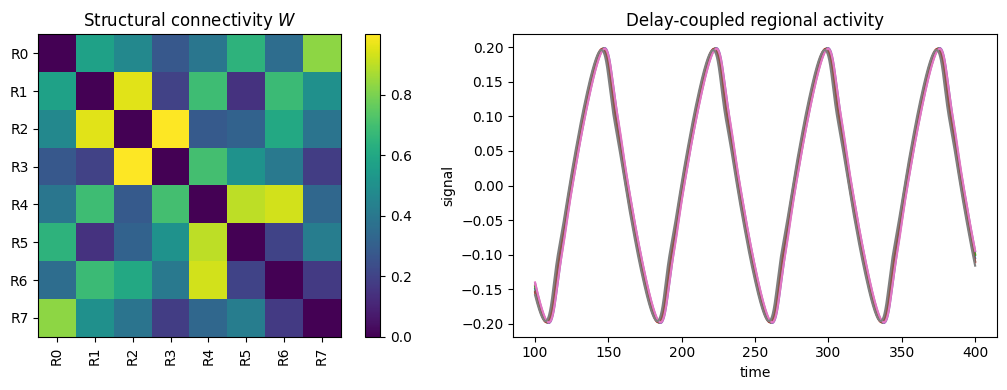

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# The structural connectivity that wired the network.
brainmass.viz.plot_connectivity(conn.weights, labels=list(conn.labels), ax=ax1)
ax1.set_title('Structural connectivity $W$')

# The resulting coupled regional activity.
brainmass.viz.plot_timeseries(res['output'], ts=res['ts'], ax=ax2)
ax2.set_title('Delay-coupled regional activity')

fig.tight_layout()
plt.show()

The left panel is the anatomy ($W$); the right is the dynamics it produces once the
regions are coupled with conduction delays. Change $k$, the speed, or the coupling
function and the collective behaviour — synchrony, metastability, travelling
patterns — changes with it. Exploring that map from *wiring* to *dynamics* is much
of what whole-brain modelling is about.

## Key takeaways

- **Structural connectivity** $W$ is the wiring diagram; zero its diagonal and
  scale it by a global strength $k$ ($\equiv$ TVB's $G$).
- **Conduction delays** $\tau_{ij} = d_{ij}/v$ come from a distance matrix and a
  finite speed; they are essential for realistic large-scale dynamics and need a
  delay buffer (built automatically by ``Network``).
- **Diffusive** coupling is *relative* (a Laplacian pull toward consensus),
  **additive** is *absolute* (direct injected drive), and **nonlinear** couplings
  add synaptic saturation, split into post- and pre-nonlinearity forms.

## See also

- {doc}`/howto/custom_coupling` — swapping coupling functions in practice.
- {doc}`/tutorials/04_building_a_network` — building a connectome network step by step.
- {doc}`/concepts/architecture_overview` — where ``Network`` sits in the package.
- {doc}`/concepts/what_is_a_neural_mass_model` — the per-region nodes being coupled.

## References

- Sanz-Leon, P., Knock, S. A., Spiegler, A., & Jirsa, V. K. (2015). Mathematical
  framework for large-scale brain network modeling in The Virtual Brain.
  *NeuroImage*, 111, 385–430.
- Deco, G., Jirsa, V., McIntosh, A. R., Sporns, O., & Kötter, R. (2009). Key role
  of coupling, delay, and noise in resting brain fluctuations. *PNAS*, 106(25),
  10302–10307.
- Honey, C. J., et al. (2009). Predicting human resting-state functional
  connectivity from structural connectivity. *PNAS*, 106(6), 2035–2040.